# Plot preview - simulated data

Renders every figure in `hazel_gp.results` with **synthetic** predictions, so the output can
be judged before any real Hazel results exist.

**Nothing here is a scientific result.** Predictions come from a random generator, not from a
fitted GP. The ranking of the five representations is invented and carries no meaning
whatsoever; only the *formatting* of these figures and tables is real.

The notebook writes no files and neither reads nor modifies `data_hazel/` or `exports/`. It
sits in `scratch/`, which `create_upload_archive` does not collect, so it never reaches the
cluster. Presentation styling has **not** been applied yet.

In [1]:
import sys
from pathlib import Path

PROJECT = Path.cwd().parent if Path.cwd().name == "scratch" else Path.cwd()
assert (PROJECT / "hazel_gp").is_dir(), f"Cannot locate hazel_gp from {Path.cwd()}"
sys.path.insert(0, str(PROJECT))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

from hazel_gp.results import (regression_metrics, model_label, method_label,
                              rank_models, rank_table, lolo_report,
                              plot_parity, plot_mean_trend,
                              plot_lolo_parity_set, plot_lolo_trend_set,
                              plot_lolo_comparison)

pd.set_option("display.width", 140)
print(f"project     {PROJECT}")
print(f"matplotlib  {mpl.__version__}")
print(f"rcParams    figsize={mpl.rcParams['figure.figsize']}  font={mpl.rcParams['font.size']}  "
      f"dpi={mpl.rcParams['figure.dpi']}")

project     C:\Users\koand\Downloads\hazel_gp_workflow
matplotlib  3.10.8
rcParams    figsize=[6.4, 4.8]  font=10.0  dpi=100.0


## Simulated results

Mirrors the shape of the real collected tables: 22 splits per model across the five
representations, giving the same 110-fit total. Yields follow a skewed 0-100 distribution
like the original UV-area data.

In [2]:
RNG = np.random.default_rng(20260910)
LIGANDS = ["XPhos", "SPhos", "P(tBu)3", "P(o-Tol)3", "CataCXium A", "P(Cy)3", "P(Ph)3", "AmPhos"]
MODELS = ["ligand_ohe", "selected_5", "selected_2", "pc_top", "pc_scores"]
PER_LIGAND, N_FOLDS = 384, 5

# Illustrative spread per representation. Invented, not measured.
MODEL_ERROR = {"ligand_ohe": 21.0, "selected_5": 14.5, "selected_2": 16.5,
               "pc_top": 13.5, "pc_scores": 11.5}

ligand_of = np.repeat(LIGANDS, PER_LIGAND)
n_rows = len(ligand_of)
row_ids = np.array([f"reaction:{i + 1}" for i in range(n_rows)])
# Mostly low yields with a tail of good ones, as in the original data.
y_all = np.clip(RNG.beta(1.4, 3.0, n_rows) * 115.0, 0.0, 100.0)
ligand_bias = dict(zip(LIGANDS, RNG.normal(0.0, 5.0, len(LIGANDS))))

splits = []  # (method, reference_group, repeat, fold, test_index)
for lig in LIGANDS:
    splits.append(("lolo", lig, "", "", np.flatnonzero(ligand_of == lig)))
# Matched IID: the same eight-fold geometry, random membership, every row tested once.
shuffled = RNG.permutation(n_rows)
for fold in range(len(LIGANDS)):
    splits.append(("iid_matched", "", "", fold,
                   np.sort(shuffled[fold * PER_LIGAND:(fold + 1) * PER_LIGAND])))
order = RNG.permutation(n_rows)
for fold, part in enumerate(np.array_split(order, N_FOLDS)):
    splits.append(("kfold", "", "", fold, np.sort(part)))
splits.append(("holdout", "", "", "", np.sort(order[:int(0.2 * n_rows)])))

print(f"{len(splits)} splits x {len(MODELS)} models = {len(splits) * len(MODELS)} simulated fits")

22 splits x 5 models = 110 simulated fits


In [3]:
frames, metric_rows, task_id = [], [], 0
for model in MODELS:
    for split_no, (method, ref, repeat, fold, idx) in enumerate(splits):
        scale = MODEL_ERROR[model] * (1.55 if method == "lolo" else 1.0)
        bias = ligand_bias[ref] if method == "lolo" else 0.0
        y = y_all[idx]
        pred = y + RNG.normal(bias, scale, len(idx))
        std = scale * (0.70 + 0.40 * RNG.random(len(idx)))  # under-dispersed on purpose
        common = {"task_id": task_id, "model": model, "method": method,
                  "reference_group": ref, "split_id": f"split_{split_no:03d}",
                  "repeat": repeat, "fold": fold}
        frames.append(pd.DataFrame({**common, "test_index": idx, "row_id": row_ids[idx],
                                    "ligand": ligand_of[idx], "y_true": y,
                                    "y_pred": pred, "predictive_std": std}))
        metric_rows.append({**common, **regression_metrics(y, pred, std)})
        task_id += 1

predictions = pd.concat(frames, ignore_index=True)
metrics_by_split = pd.DataFrame(metric_rows)
tables = {"predictions": predictions, "metrics_by_split": metrics_by_split}

print(f"{len(predictions):,} prediction rows | {len(metrics_by_split)} split-metric rows")

49,150 prediction rows | 110 split-metric rows


# 1. The four experiment types

Every figure heading now reads `representation | experiment | held-out ligand`, using display
names rather than config keys, so it is unambiguous which experiment produced a plot.
`pc_scores` shows as **PC loading**, and the four evaluation methods map to **LOLO**,
**Matched IID**, **5-fold CV** and **80:20 split**.

These four answer genuinely different questions and are not interchangeable.

In [4]:
NOTES = {
    "lolo": "Train on 7 ligands, test every row of the 8th. Out-of-distribution: "
            "the held-out ligand is unseen.",
    "iid_matched": "The same eight-fold geometry as LOLO, sized to each LOLO test set, but "
                   "with random membership so every ligand appears in training. Every row "
                   "tested exactly once. The in-distribution control for LOLO.",
    "kfold": "KFold(5, shuffle=True, random_state=42) over all rows. Interpolation "
             "within the explored space.",
    "holdout": "train_test_split(test_size=0.2, random_state=42). Retained to match the "
               "original notebook; with seed 42 its test set equals the first 5-fold test "
               "set, so it is not an independent experiment.",
}

overview = []
for method in dict.fromkeys(predictions.method):
    part = predictions[predictions.method == method]
    overview.append({"config key": method, "experiment": method_label(method),
                     "splits per model": part.split_id.nunique(),
                     "test rows per split":
                         int(len(part) / (part.split_id.nunique() * part.model.nunique())),
                     "what it measures": NOTES[method]})

display(pd.DataFrame(overview).style.set_properties(
    subset=["what it measures"], **{"white-space": "pre-wrap", "text-align": "left"}))

,config key,experiment,splits per model,test rows per split,what it measures
0,lolo,LOLO,8,384,"Train on 7 ligands, test every row of the 8th. Out-of-distribution: the held-out ligand is unseen."
1,iid_matched,Matched IID,8,384,"The same eight-fold geometry as LOLO, sized to each LOLO test set, but with random membership so every ligand appears in training. Every row tested exactly once. The in-distribution control for LOLO."
2,kfold,5-fold CV,5,614,"KFold(5, shuffle=True, random_state=42) over all rows. Interpolation within the explored space."
3,holdout,80:20 split,1,614,"train_test_split(test_size=0.2, random_state=42). Retained to match the original notebook; with seed 42 its test set equals the first 5-fold test set, so it is not an independent experiment."


# 2. LOLO - one figure per held-out ligand, then pooled

Observed against predicted, with no ligand colouring or legend. $R^2$ and RMSE sit under each
heading, computed from exactly the points drawn.

`plot_lolo_parity_set` returns `[(held-out ligand, figure), ...]` with the pooled figure last,
so all eight folds and the pooled view come from a single call.

'pc_scores' displays as 'PC loading'


--- LOLO, held-out: AmPhos ---


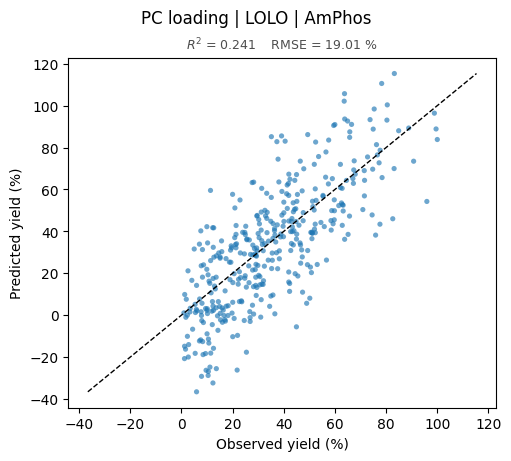

--- LOLO, held-out: CataCXium A ---


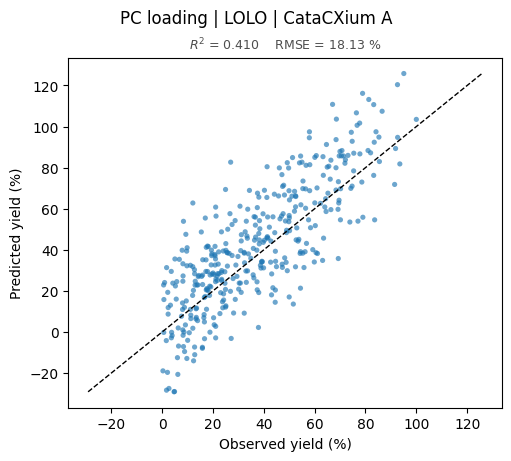

--- LOLO, held-out: P(Cy)3 ---


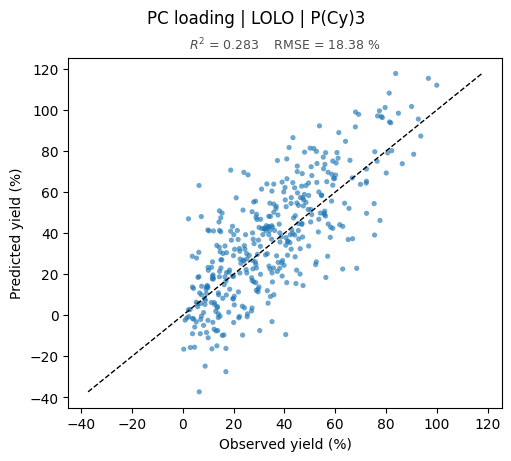

--- LOLO, held-out: P(Ph)3 ---


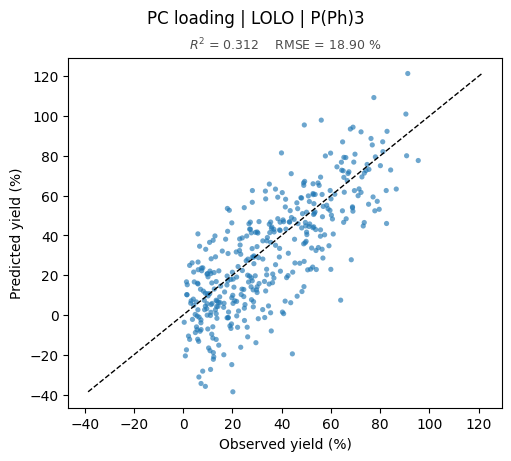

--- LOLO, held-out: P(o-Tol)3 ---


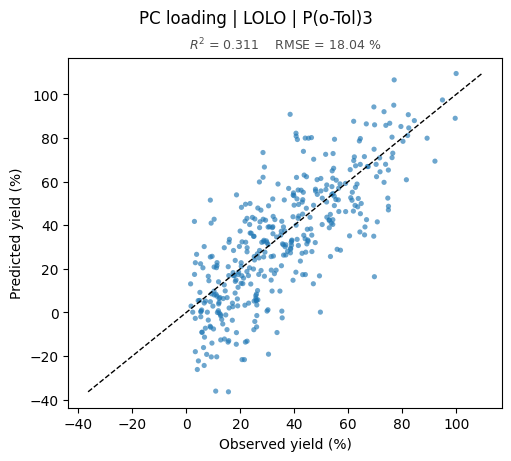

--- LOLO, held-out: P(tBu)3 ---


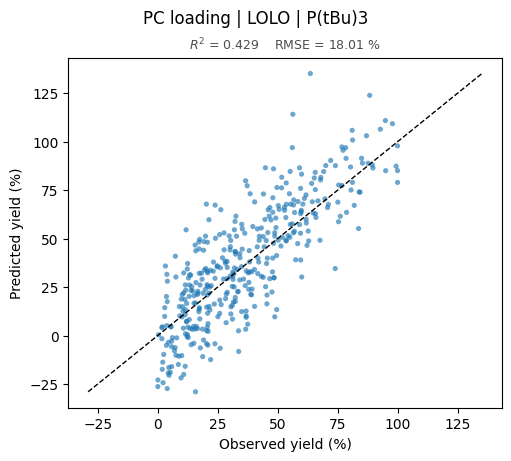

--- LOLO, held-out: SPhos ---


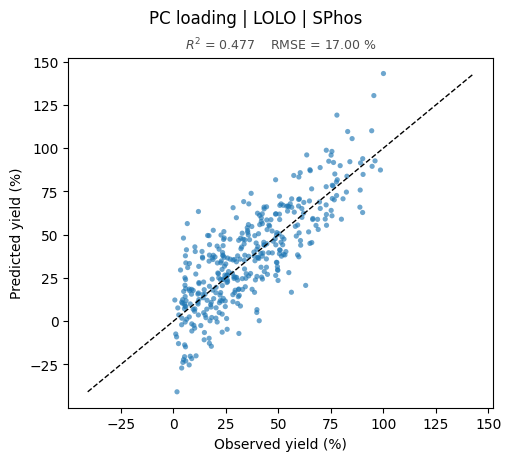

--- LOLO, held-out: XPhos ---


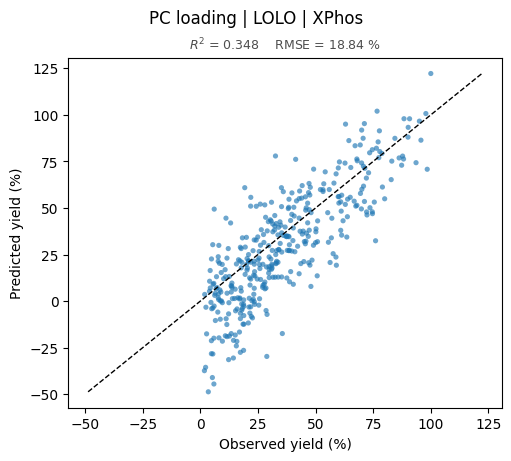

--- LOLO, held-out: all ligands pooled ---


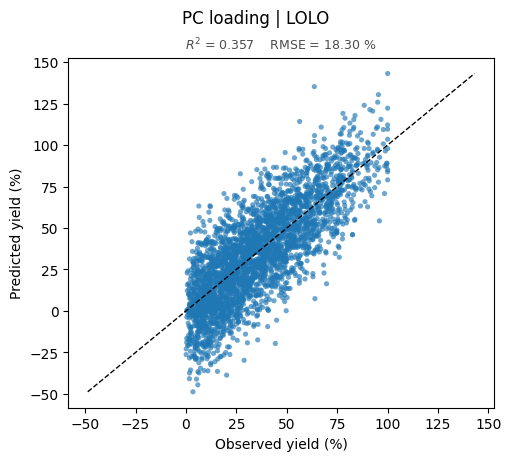

In [5]:
MODEL = "pc_scores"
print(f"{MODEL!r} displays as {model_label(MODEL)!r}")

for label, fig in plot_lolo_parity_set(predictions, MODEL):
    print(f"--- LOLO, held-out: {label} ---")
    display(fig)
    plt.close(fig)

### LOLO mean trend, $\pm$1 std band

Observed yield is binned; the mean prediction per bin is a line and one standard deviation is
shaded. `band="empirical"` (the default) shades the observed spread of the predictions.
`band="predictive"` shades the mean predictive standard deviation the GP itself reported,
which is its claimed uncertainty rather than the realised error.

--- LOLO trend, held-out: AmPhos ---


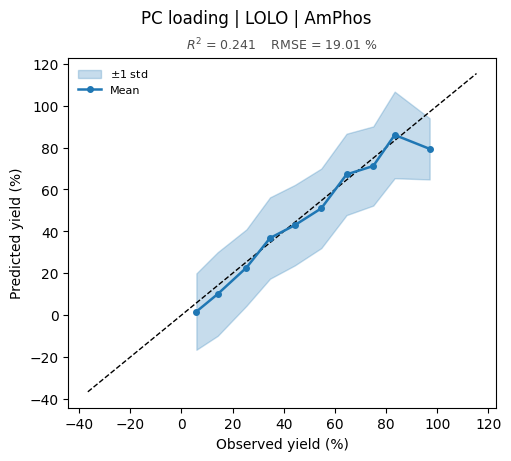

--- LOLO trend, held-out: CataCXium A ---


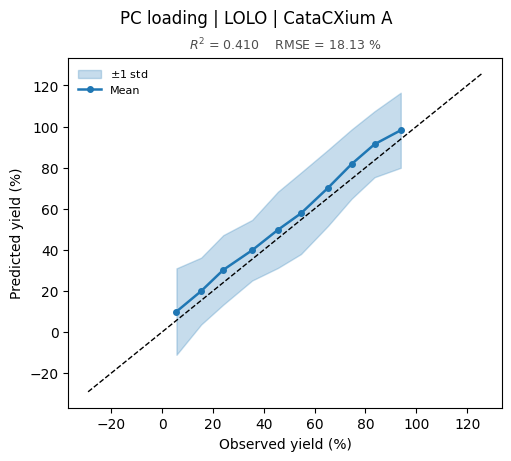

--- LOLO trend, held-out: P(Cy)3 ---


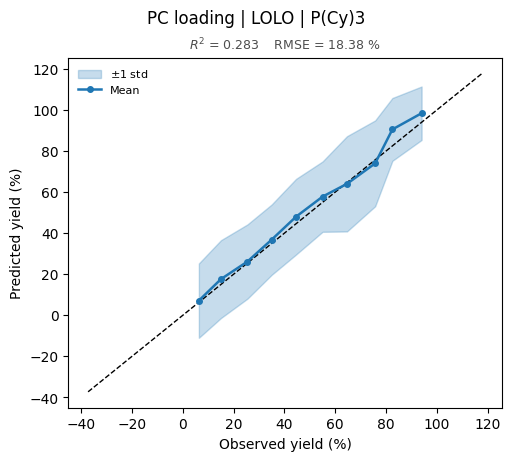

--- LOLO trend, held-out: P(Ph)3 ---


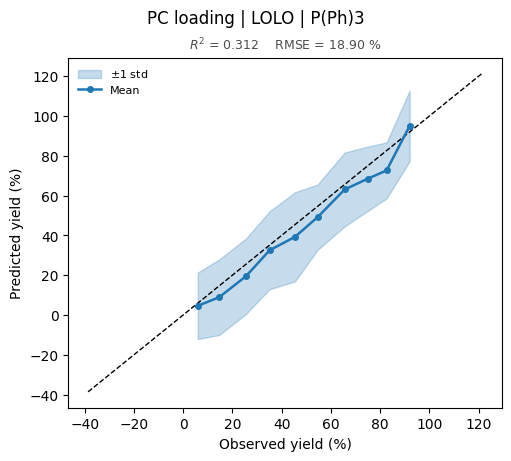

--- LOLO trend, held-out: P(o-Tol)3 ---


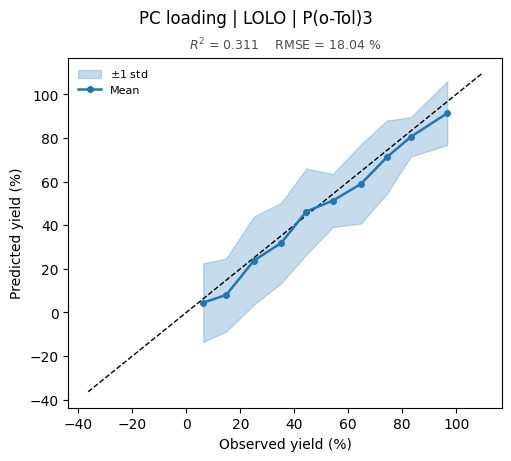

--- LOLO trend, held-out: P(tBu)3 ---


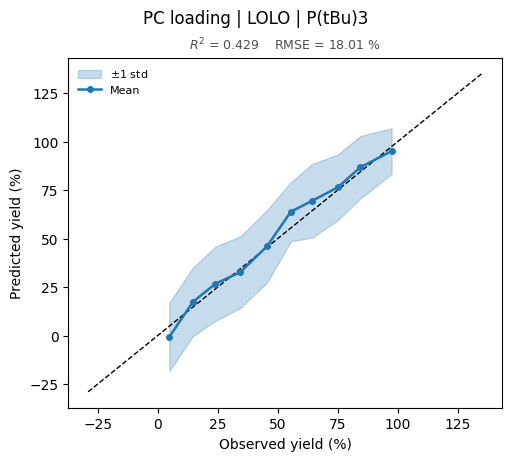

--- LOLO trend, held-out: SPhos ---


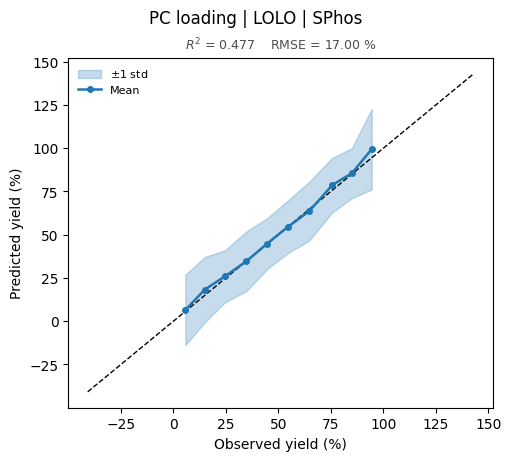

--- LOLO trend, held-out: XPhos ---


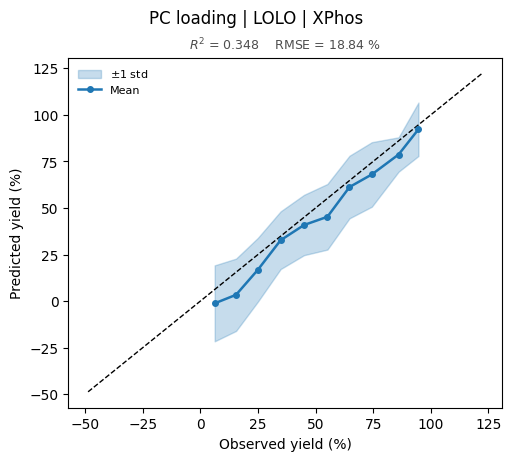

--- LOLO trend, held-out: all ligands pooled ---


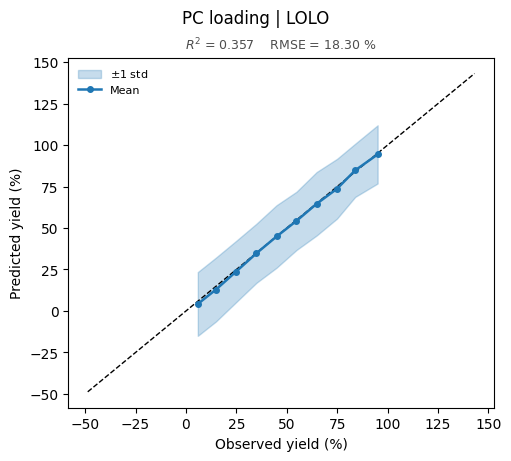

In [6]:
for label, fig in plot_lolo_trend_set(predictions, MODEL, bins=10):
    print(f"--- LOLO trend, held-out: {label} ---")
    display(fig)
    plt.close(fig)

### LOLO reported three ways

`lolo_report` puts all three views in one table, tagged by a `view` column:

| view | meaning |
| --- | --- |
| `per_ligand` | each held-out ligand alone, scored on its own 384 reactions |
| `mean_across_ligands` | unweighted mean of those eight rows; every ligand counts once |
| `pooled_over_folds` | all eight folds concatenated into one out-of-fold vector, scored once; every reaction counts once |

The averaged and pooled values are **not interchangeable**. Pooled $R^2$ is measured against
the variance of the whole dataset, a per-ligand $R^2$ against the variance within that single
ligand, which is smaller - so the averaged figure is systematically the harsher one. Pooled
RMSE is the root of the mean squared error while the averaged figure is the mean of per-fold
roots, so the pooled value is the larger. Report which one you mean.

In [7]:
report = lolo_report(predictions, metrics_by_split, models=[MODEL])
display(report[["model", "view", "scope", "n_test", "r2", "rmse", "mae", "kendall_tau"]].round(3))

,model,view,scope,n_test,r2,rmse,mae,kendall_tau
0,PC loading,per_ligand,XPhos,384.0,0.348,18.845,15.075,0.611
1,PC loading,per_ligand,SPhos,384.0,0.477,16.998,13.658,0.596
2,PC loading,per_ligand,P(tBu)3,384.0,0.429,18.013,14.383,0.611
3,PC loading,per_ligand,P(o-Tol)3,384.0,0.311,18.044,14.139,0.575
4,PC loading,per_ligand,CataCXium A,384.0,0.410,18.131,14.878,0.600
5,PC loading,per_ligand,P(Cy)3,384.0,0.283,18.376,14.774,0.555
6,PC loading,per_ligand,P(Ph)3,384.0,0.312,18.898,15.095,0.562
7,PC loading,per_ligand,AmPhos,384.0,0.241,19.014,15.221,0.569
8,PC loading,mean_across_ligands,8 ligands,NaN,0.351,18.290,14.653,0.585
9,PC loading,pooled_over_folds,8 folds,3072.0,0.357,18.300,14.653,0.580


# 3. Matched IID - the in-distribution control for LOLO

Same test-set sizes as LOLO, but every ligand is represented in training. The gap between
this and LOLO is the cost of facing an unseen ligand.

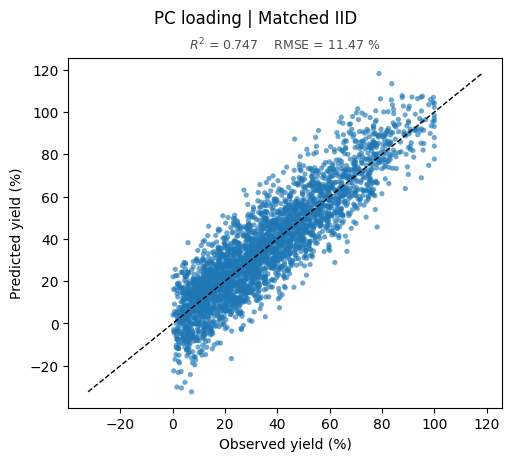

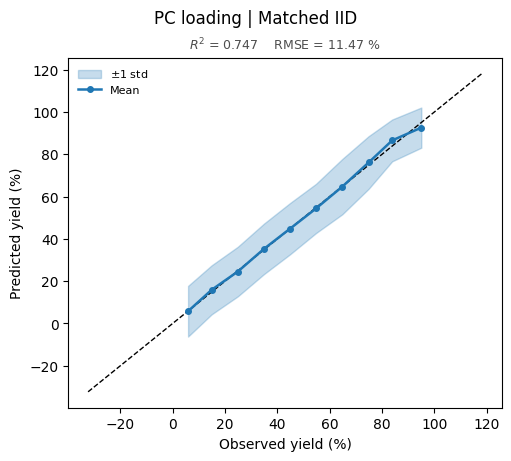

In [8]:
for fig in (plot_parity(predictions, MODEL, method="iid_matched"),
            plot_mean_trend(predictions, MODEL, method="iid_matched", bins=10)):
    display(fig)
    plt.close(fig)

# 4. 5-fold CV

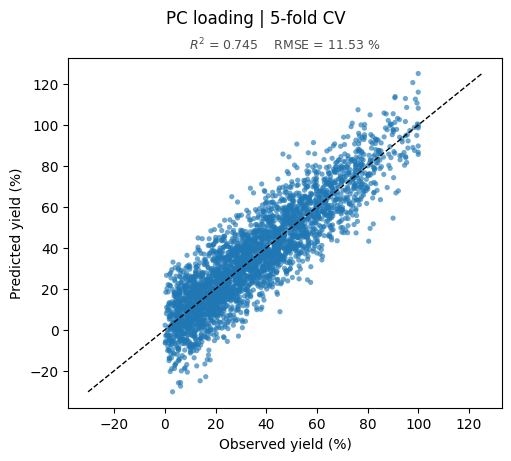

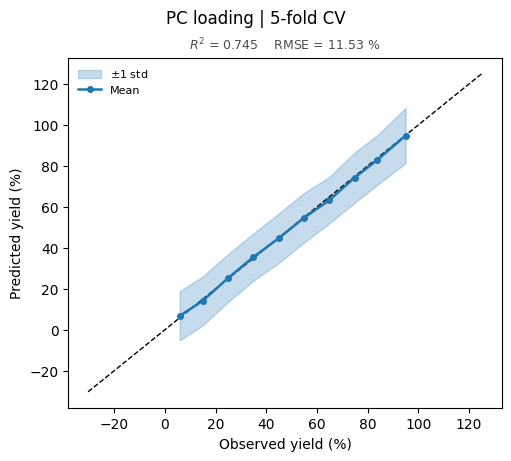

In [9]:
for fig in (plot_parity(predictions, MODEL, method="kfold"),
            plot_mean_trend(predictions, MODEL, method="kfold", bins=10)):
    display(fig)
    plt.close(fig)

# 5. 80:20 split

A single split. With seed 42 its test rows are the same as the first 5-fold test set, so read
it as a restatement of that fold, not as extra evidence.

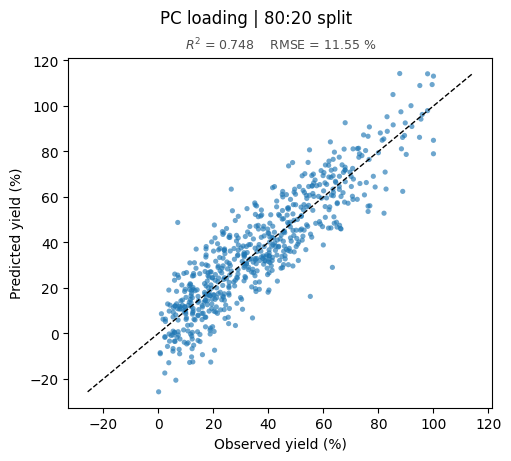

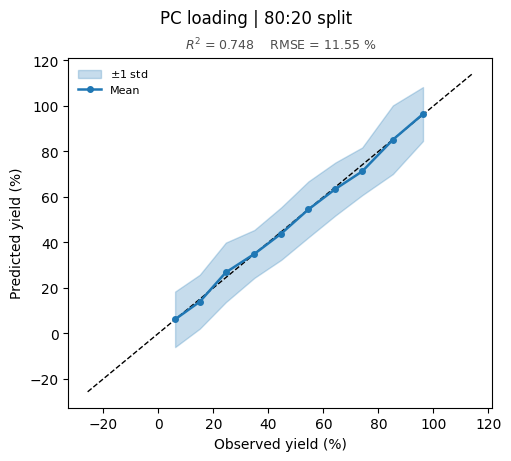

In [10]:
for fig in (plot_parity(predictions, MODEL, method="holdout"),
            plot_mean_trend(predictions, MODEL, method="holdout", bins=10)):
    display(fig)
    plt.close(fig)

### The model's own uncertainty instead of the observed scatter

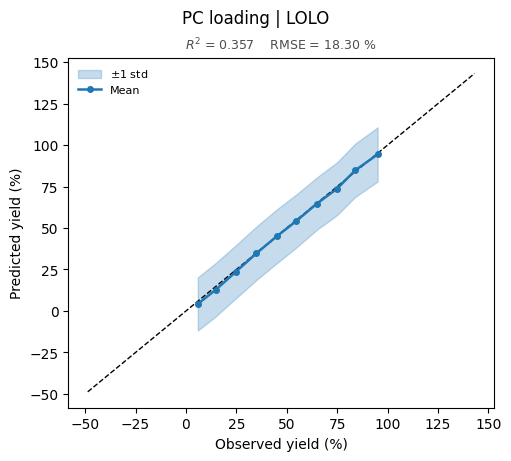

In [11]:
fig = plot_mean_trend(predictions, MODEL, method="lolo", bins=10, band="predictive")
display(fig)
plt.close(fig)

# 6. Ranked representations per experiment type

`rank_table` gives the ordering, best in column 1. `rank_models` adds the values behind it:
the mean across that experiment's splits, the spread of those splits, and how many fits
contributed.

Split metrics are averaged rather than pooled, because matched-IID repeats overlap and cannot
be treated as independent observations.

**These rank reported outcomes; they are not a model-selection procedure.** Picking a
representation by its outer test score is exactly what `README` section 4 warns against, and
would need an additional inner validation loop to be legitimate. Note also that
`std_across_splits` is often large next to the gaps between models, so neighbouring ranks may
not be separable at all.

In [12]:
for metric in ("rmse", "r2", "predictive_nll"):
    print(f"=== ranked by {metric} ({'lower' if metric != 'r2' else 'higher'} is better) ===")
    display(rank_table(metrics_by_split, metric=metric))

=== ranked by rmse (lower is better) ===


rank by rmse,1,2,3,4,5
experiment,,,,,
LOLO,PC loading,pc_top,selected_5,selected_2,ligand_ohe
Matched IID,PC loading,pc_top,selected_5,selected_2,ligand_ohe
5-fold CV,PC loading,pc_top,selected_5,selected_2,ligand_ohe
80:20 split,PC loading,pc_top,selected_5,selected_2,ligand_ohe


=== ranked by r2 (higher is better) ===


rank by r2,1,2,3,4,5
experiment,,,,,
LOLO,PC loading,pc_top,selected_5,selected_2,ligand_ohe
Matched IID,PC loading,pc_top,selected_5,selected_2,ligand_ohe
5-fold CV,PC loading,pc_top,selected_5,selected_2,ligand_ohe
80:20 split,PC loading,pc_top,selected_5,selected_2,ligand_ohe


=== ranked by predictive_nll (lower is better) ===


rank by predictive_nll,1,2,3,4,5
experiment,,,,,
LOLO,PC loading,pc_top,selected_5,selected_2,ligand_ohe
Matched IID,PC loading,pc_top,selected_5,selected_2,ligand_ohe
5-fold CV,PC loading,pc_top,selected_5,selected_2,ligand_ohe
80:20 split,PC loading,pc_top,selected_5,selected_2,ligand_ohe


In [13]:
display(rank_models(metrics_by_split, metric="rmse").round(3))

,experiment,rank,model,mean_rmse,std_across_splits,fits,better
0,LOLO,1,PC loading,18.290,0.659,8,lower
1,LOLO,2,pc_top,21.392,0.657,8,lower
2,LOLO,3,selected_5,22.475,0.685,8,lower
3,LOLO,4,selected_2,25.872,0.990,8,lower
4,LOLO,5,ligand_ohe,32.387,0.825,8,lower
5,Matched IID,1,PC loading,11.464,0.395,8,lower
6,Matched IID,2,pc_top,13.533,0.354,8,lower
7,Matched IID,3,selected_5,14.282,0.365,8,lower
8,Matched IID,4,selected_2,16.400,0.581,8,lower
9,Matched IID,5,ligand_ohe,20.464,1.076,8,lower


# 7. Per-ligand comparison across representations

Bars follow the config order (`ligand_ohe, selected_5, selected_2, pc_top, pc_scores`) rather
than the alphabetical order `pivot` used to produce, and `pc_scores` appears as PC loading.

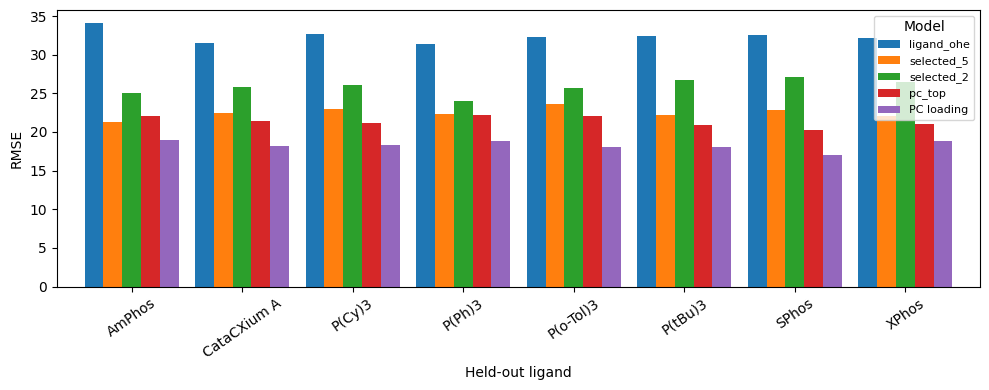

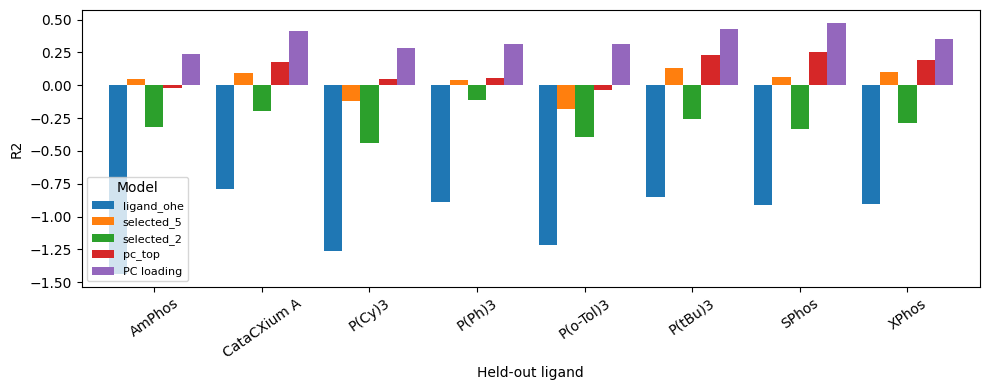

In [14]:
for metric in ("rmse", "r2"):
    fig = plot_lolo_comparison(metrics_by_split, metric=metric)
    display(fig)
    plt.close(fig)

# 8. Split sizes across representations

All five representations read the same split registry, so a given `split_id` hands every one
of them the same rows. This confirms it from the split entries rather than assuming it, and
checks that each matched-IID split really does match its LOLO reference's sizes.

The one thing that legitimately varies is the *column* count for `ligand_ohe`: a LOLO training
fold never sees the held-out ligand, so its one-hot block is one column narrower. That is a
width difference, not a row difference.

In [15]:
entries = pd.DataFrame([{"split_id": f"split_{i:03d}", "method": method,
                         "reference_group": ref, "n_train": n_rows - len(idx),
                         "n_test": len(idx)}
                        for i, (method, ref, _, _, idx) in enumerate(splits)])

sizes = (entries.groupby("method", sort=False)
         .agg(splits=("split_id", "size"),
              n_train=("n_train", lambda s: sorted(s.unique())),
              n_test=("n_test", lambda s: sorted(s.unique()))))
sizes.index = [method_label(m) for m in sizes.index]
display(sizes)

def fold_sizes(method):
    part = entries[entries.method == method].sort_values("split_id")
    return [(row.n_train, row.n_test) for row in part.itertuples()]

lolo_sizes, iid_sizes = fold_sizes("lolo"), fold_sizes("iid_matched")
print(f"LOLO folds  {len(lolo_sizes)}, sizes {sorted(set(lolo_sizes))}")
print(f"IID folds   {len(iid_sizes)}, sizes {sorted(set(iid_sizes))}")
print(f"IID matches LOLO fold for fold: {lolo_sizes == iid_sizes}")

for method in ("lolo", "iid_matched", "kfold"):
    tested = np.concatenate([idx for m, _, _, _, idx in splits if m == method])
    once = len(tested) == n_rows and len(np.unique(tested)) == n_rows
    print(f"  {method_label(method):<12} every row tested exactly once, never repeated: {once}")

rows_per_model = predictions.groupby(["split_id", "model"]).size().unstack("model")
inconsistent = rows_per_model[rows_per_model.nunique(axis=1) > 1]
print(f"splits where representations disagree on test row count: {len(inconsistent)}")

,splits,n_train,n_test
LOLO,8,[2688],[384]
Matched IID,8,[2688],[384]
5-fold CV,5,"[2457, 2458]","[614, 615]"
80:20 split,1,[2458],[614]


LOLO folds  8, sizes [(2688, 384)]
IID folds   8, sizes [(2688, 384)]
IID matches LOLO fold for fold: True
  LOLO         every row tested exactly once, never repeated: True
  Matched IID  every row tested exactly once, never repeated: True
  5-fold CV    every row tested exactly once, never repeated: True
splits where representations disagree on test row count: 0


# 9. Interactive picker

Calibration figures (the PIT CDF plots) were removed on request. `plot_calibration` is still
in `hazel_gp.results`, with a docstring explaining how to read one, so it is a one-line import
away if ever wanted; `pit_cdf_mae` also remains in the metrics tables as a single number.

Below is the control used by `02_review_results.ipynb`. It needs `ipywidgets` and a live
kernel, so it renders as nothing in a saved non-interactive execution - run this one cell to
try it.

In [16]:
from hazel_gp.notebook import review_controls

display(review_controls(tables))

# 10. Current style settings

Every value below is hardcoded in `hazel_gp/results.py`; none are read from `rcParams`, so a
global `plt.style.use(...)` will not move them. This is the list to edit for the presentation
pass.

In [17]:
knobs = pd.DataFrame(
    [("plot_parity", "figsize", "(5, 4.5), constrained_layout=True"),
     ("plot_parity", "markers", "s=14, alpha=0.65, tab:blue, edgecolors none"),
     ("plot_parity", "diagonal", "black, linestyle '--', linewidth 1"),
     ("plot_parity", "axis range", "min(0, pred.min()) to max(100, pred.max())"),
     ("plot_parity", "heading", "fig.suptitle, default size"),
     ("plot_parity", "score line", "ax.set_title, fontsize 9, colour '0.3'"),
     ("plot_mean_trend", "figsize", "(5, 4.5), constrained_layout=True"),
     ("plot_mean_trend", "band", "tab:blue, alpha 0.25"),
     ("plot_mean_trend", "mean line", "tab:blue, marker 'o', ms 4, lw 1.8"),
     ("plot_mean_trend", "bins", "10 equal-width over 0-100 (argument)"),
     ("plot_mean_trend", "legend", "fontsize 8, frameon=False"),
     ("plot_lolo_comparison", "figsize", "(10, 4)"),
     ("plot_lolo_comparison", "bars", "pandas .plot.bar, width=0.85"),
     ("plot_lolo_comparison", "tick labels", "x rotation 35"),
     ("plot_lolo_comparison", "legend", "title 'Model', fontsize 8"),
     ("plot_lolo_comparison", "layout", "tight_layout()")],
    columns=["function", "knob", "current value"])

display(knobs)

,function,knob,current value
0,plot_parity,figsize,"(5, 4.5), constrained_layout=True"
1,plot_parity,markers,"s=14, alpha=0.65, tab:blue, edgecolors none"
2,plot_parity,diagonal,"black, linestyle '--', linewidth 1"
3,plot_parity,axis range,"min(0, pred.min()) to max(100, pred.max())"
4,plot_parity,heading,"fig.suptitle, default size"
5,plot_parity,score line,"ax.set_title, fontsize 9, colour '0.3'"
6,plot_mean_trend,figsize,"(5, 4.5), constrained_layout=True"
7,plot_mean_trend,band,"tab:blue, alpha 0.25"
8,plot_mean_trend,mean line,"tab:blue, marker 'o', ms 4, lw 1.8"
9,plot_mean_trend,bins,10 equal-width over 0-100 (argument)


# 11. Trying a different look

Anything hardcoded above overrides these, so the table in section 10 is what needs a real
code edit rather than an rcParams tweak.

In [18]:
# mpl.rcParams.update({
#     "figure.dpi": 120,
#     "axes.grid": True,
#     "grid.alpha": 0.3,
#     "axes.spines.top": False,
#     "axes.spines.right": False,
#     "font.size": 11,
# })
# plt.style.use("seaborn-v0_8-whitegrid")
print("Available styles:", ", ".join(plt.style.available))

Available styles: Solarize_Light2, _classic_test_patch, _mpl-gallery, _mpl-gallery-nogrid, bmh, classic, dark_background, fast, fivethirtyeight, ggplot, grayscale, petroff10, seaborn-v0_8, seaborn-v0_8-bright, seaborn-v0_8-colorblind, seaborn-v0_8-dark, seaborn-v0_8-dark-palette, seaborn-v0_8-darkgrid, seaborn-v0_8-deep, seaborn-v0_8-muted, seaborn-v0_8-notebook, seaborn-v0_8-paper, seaborn-v0_8-pastel, seaborn-v0_8-poster, seaborn-v0_8-talk, seaborn-v0_8-ticks, seaborn-v0_8-white, seaborn-v0_8-whitegrid, tableau-colorblind10
